# 03. Model Training and Comparison

Notebook này dùng để huấn luyện nhiều mô hình và so sánh chúng bằng **nhiều sơ đồ cột**.

Các model chính:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- AdaBoost
- XGBoost
- LightGBM
- Notebook-style Voting Ensemble
- Teacher-style Voting Ensemble

In [1]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    candidates = [start_path, *start_path.parents, DEFAULT_ROOT]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục project chứa src/ và configs/.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import preprocess_pipeline
from src.models.train import train_all_models
from src.models.evaluate import evaluate_models
from src.utils.config import load_project_config

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
bundle = preprocess_pipeline(df, config)

## 1. Huấn luyện toàn bộ mô hình

In [2]:
trained_models, tuning_summary = train_all_models(bundle.X_train, bundle.y_train, config)
results_df, report_map = evaluate_models(trained_models, bundle.X_test, bundle.y_test)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,adaboost,0.748048,0.517691,0.743316,0.610318,0.827383
1,teacher_voting_ensemble,0.767211,0.550439,0.671123,0.604819,0.830180
2,random_forest,0.765791,0.548246,0.668449,0.602410,0.827951
3,lightgbm,0.775018,0.568019,0.636364,0.600252,0.823057
4,xgboost,0.763662,0.544662,0.668449,0.600240,0.829439
5,gradient_boosting,0.757275,0.533333,0.684492,0.599532,0.828262
6,notebook_voting_ensemble,0.747339,0.517647,0.705882,0.597285,0.826619
7,logistic_regression,0.736693,0.502814,0.716578,0.590959,0.815531
8,decision_tree,0.751597,0.527149,0.622995,0.571078,0.797295


## 2. So sánh nhanh theo F1-score và Accuracy

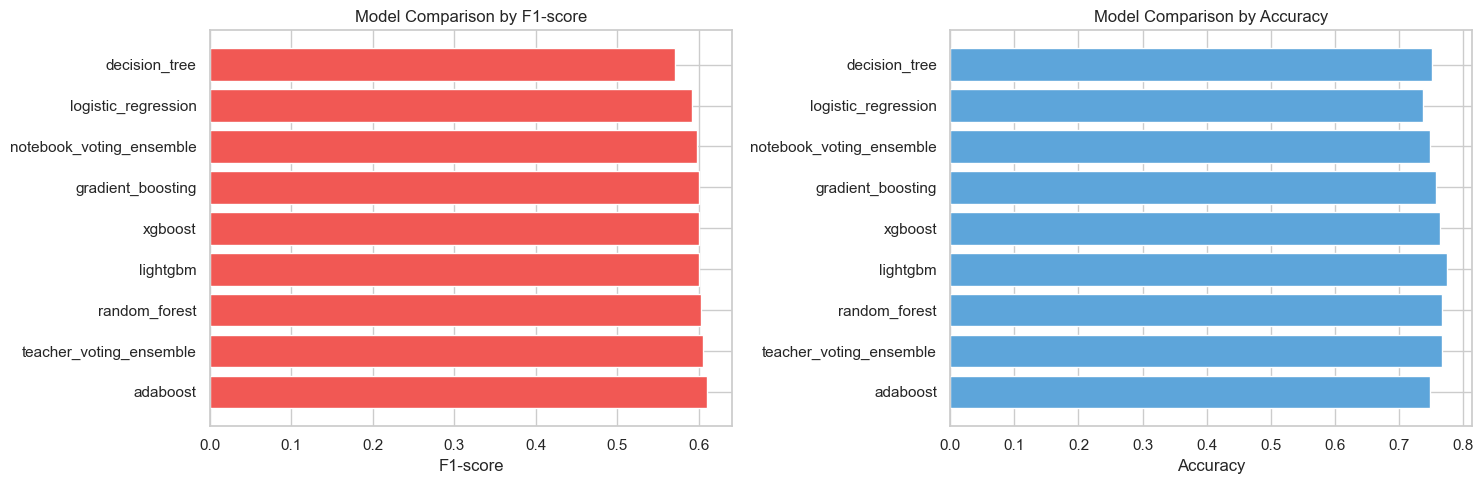

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(results_df['model'], results_df['f1'], color='#F15854')
axes[0].set_title('Model Comparison by F1-score')
axes[0].set_xlabel('F1-score')

axes[1].barh(results_df['model'], results_df['accuracy'], color='#5DA5DA')
axes[1].set_title('Model Comparison by Accuracy')
axes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.show()

## 3. Biểu đồ cột so sánh toàn bộ metric chính

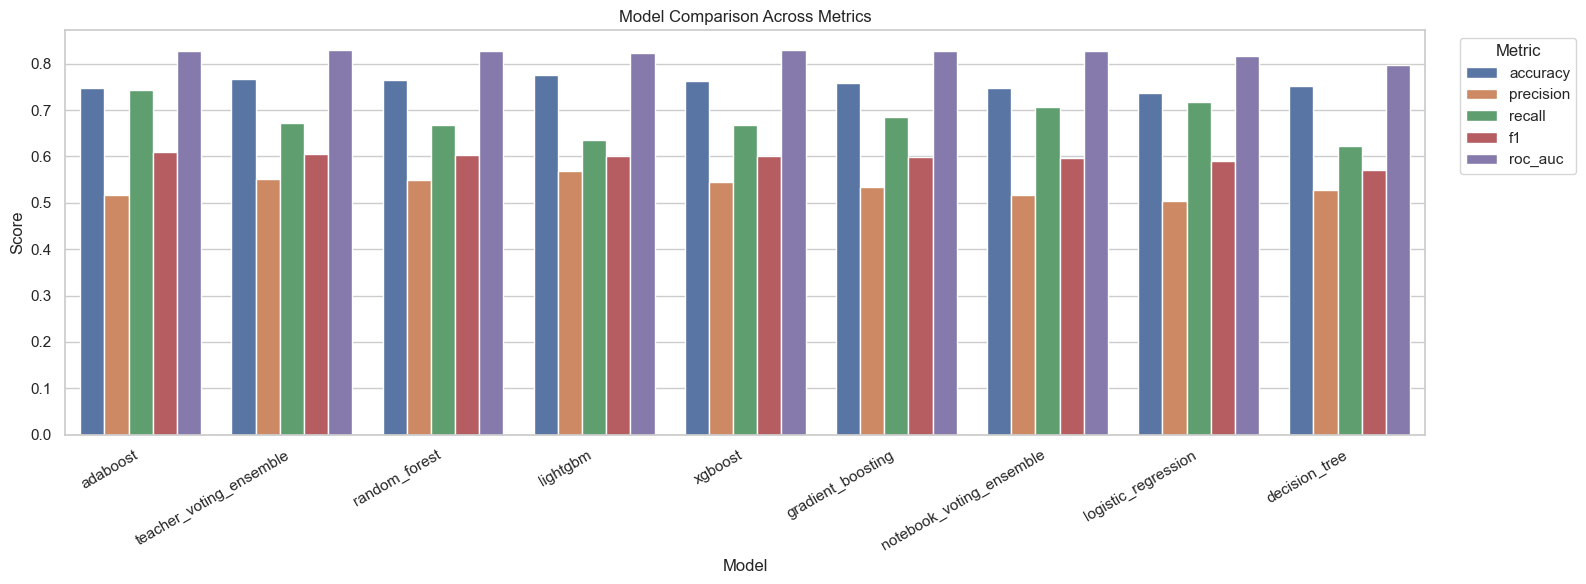

In [4]:
metric_columns = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
long_df = results_df.melt(id_vars='model', value_vars=metric_columns, var_name='metric', value_name='score')

plt.figure(figsize=(16, 6))
sns.barplot(data=long_df, x='model', y='score', hue='metric')
plt.title('Model Comparison Across Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. So sánh Precision, Recall, F1-score của các model mạnh

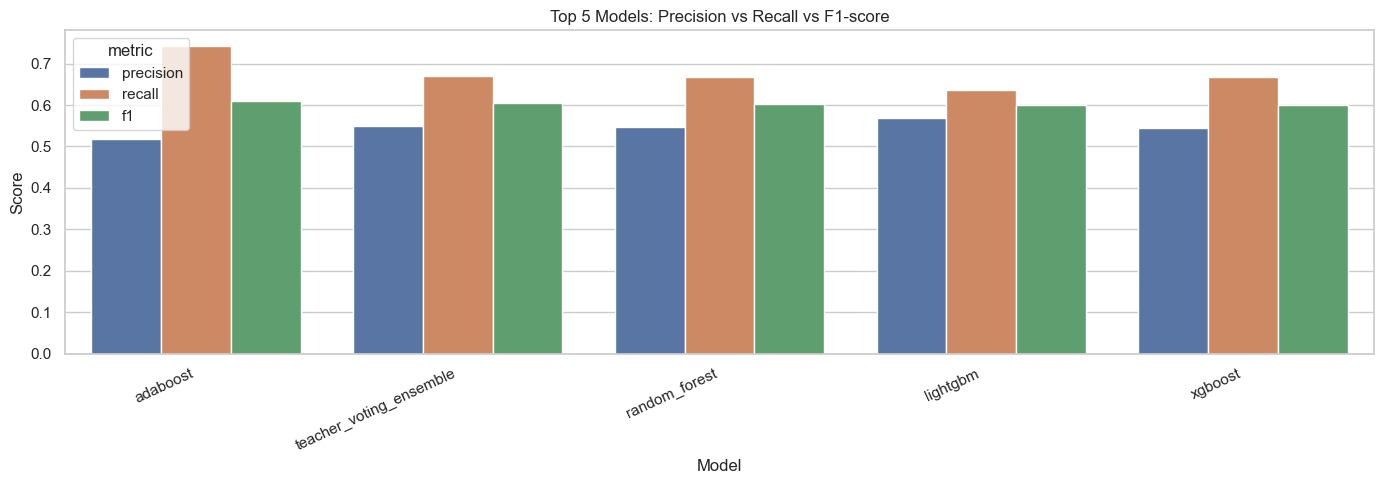

In [5]:
top_models = results_df.head(5).copy()
top_metric_df = top_models.melt(id_vars='model', value_vars=['precision', 'recall', 'f1'], var_name='metric', value_name='score')

plt.figure(figsize=(14, 5))
sns.barplot(data=top_metric_df, x='model', y='score', hue='metric')
plt.title('Top 5 Models: Precision vs Recall vs F1-score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 5. So sánh các model ensemble với model đơn

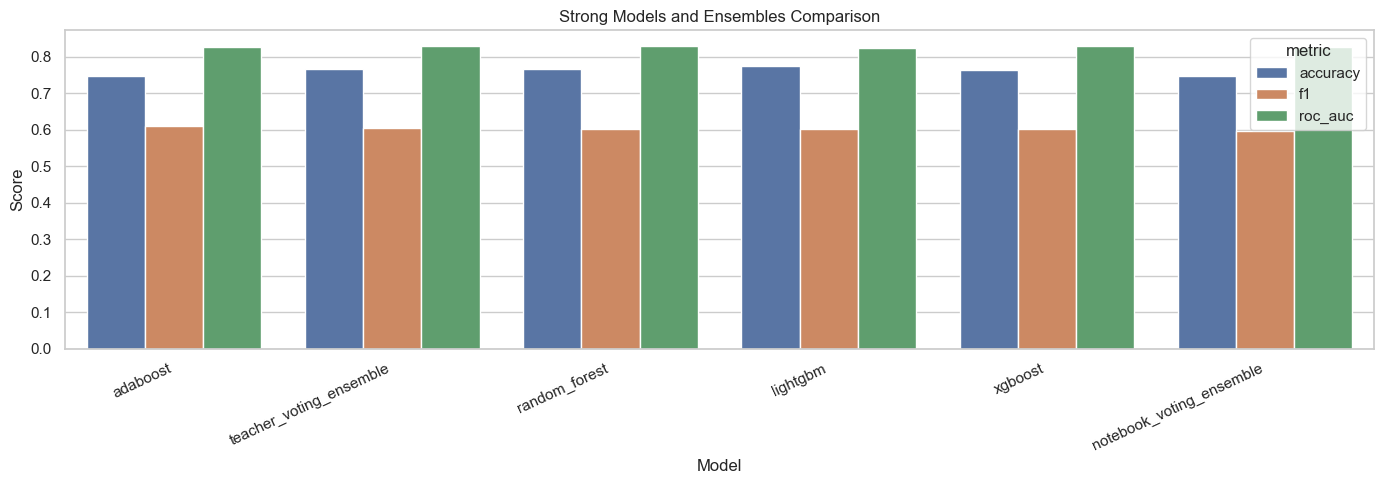

In [6]:
focus_models = results_df[results_df['model'].isin(['random_forest', 'xgboost', 'lightgbm', 'adaboost', 'notebook_voting_ensemble', 'teacher_voting_ensemble'])].copy()
focus_long = focus_models.melt(id_vars='model', value_vars=['accuracy', 'f1', 'roc_auc'], var_name='metric', value_name='score')

plt.figure(figsize=(14, 5))
sns.barplot(data=focus_long, x='model', y='score', hue='metric')
plt.title('Strong Models and Ensembles Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 6. Top 3 model tốt nhất

In [7]:
top3_df = results_df.head(3).copy()
top3_df

,model,accuracy,precision,recall,f1,roc_auc
0,adaboost,0.748048,0.517691,0.743316,0.610318,0.827383
1,teacher_voting_ensemble,0.767211,0.550439,0.671123,0.604819,0.830180
2,random_forest,0.765791,0.548246,0.668449,0.602410,0.827951


In [8]:
best_model_name = results_df.iloc[0]['model']
print('Best model:', best_model_name)
print('\nClassification report of best model:\n')
print(report_map[best_model_name])

Best model: adaboost

Classification report of best model:

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



## 7. Kết luận training

Các ý bạn có thể dùng để kết luận:
- Nhóm đã train nhiều model thay vì chọn ngẫu nhiên một mô hình.
- Các model boosting và ensemble thường cho kết quả mạnh hơn model cơ bản.
- Nên đánh giá dựa trên nhiều metric, đặc biệt là `F1-score` và `ROC-AUC`.
- Model tốt nhất sẽ được mang sang notebook đánh giá sâu để phân tích thêm confusion matrix, ROC curve và feature importance.